# Module 04, Part 1: Why sequences need memory

This notebook is the runnable companion to Part 1 of the Module 04 learning
content. It checks, with code, each claim the part makes about the recurrent
cell:

1. A fully connected layer on a flattened sequence has a frozen input length,
   no sharing between positions, and many more parameters.
2. A recurrent layer reuses one set of weights at every step, so it accepts
   any length with the same number of parameters.
3. The recurrence $h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$ written by hand
   gives exactly the same numbers as `nn.RNN`.
4. Two shape pitfalls: the shape of `h_n`, and what happens when
   `batch_first` is wrong.
5. A first training run on a short delayed-recall task, which a plain
   recurrent cell solves. Parts 3 and 4 make the task harder.

Everything runs on CPU in well under a minute.

In [1]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

INK, BODY, MUTED = "#14161B", "#4E5563", "#7C838C"
NAVY, GREEN, AMBER, KEY, RULE = "#1C3D6E", "#0E6B57", "#8A6A18", "#7A2E8A", "#D9DCE2"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": RULE, "axes.labelcolor": BODY, "xtick.color": BODY, "ytick.color": BODY,
    "axes.grid": True, "grid.color": RULE, "font.size": 10,
})

torch.manual_seed(0)
print("PyTorch version:", torch.__version__)

count = lambda module: sum(p.numel() for p in module.parameters())

PyTorch version: 2.10.0+cpu


## 1. A fully connected layer on a flattened sequence

Take a sequence of 60 steps with 8 features per step and 32 hidden units.
A fully connected layer needs the whole sequence flattened into one vector of
$60 \times 8 = 480$ numbers.

In [2]:
T, F, H = 60, 8, 32

window_mlp = nn.Linear(T * F, H)             # flatten 60 steps x 8 features -> 32 hidden units
rnn = nn.RNN(input_size=F, hidden_size=H, batch_first=True)

print("Fully connected layer on the flattened sequence:", count(window_mlp), "parameters")
print("Recurrent layer:                                ", count(rnn), "parameters")

x61 = torch.randn(4, 61, F)                  # one step longer than the layer was built for
try:
    window_mlp(x61.flatten(1))
except RuntimeError as err:
    print()
    print("The fully connected layer rejects a 61-step sequence:")
    print("  ", str(err)[:90])

out, h_n = rnn(x61)
print()
print("The recurrent layer accepts it unchanged, output shape:", tuple(out.shape))

Fully connected layer on the flattened sequence: 15392 parameters
Recurrent layer:                                 1344 parameters

The fully connected layer rejects a 61-step sequence:
   mat1 and mat2 shapes cannot be multiplied (4x488 and 480x32)

The recurrent layer accepts it unchanged, output shape: (4, 61, 32)


The recurrent layer has 1,344 parameters against 15,392, and it does not care
that the sequence got longer. Why the count is 1,344:

$$8 \times 32 \;+\; 32 \times 32 \;+\; 32 \;+\; 32 \;=\; 1{,}344$$

That is the input weights, the recurrent weights, and **two** bias vectors.
The learning content writes a single bias $b$; PyTorch keeps two
(`bias_ih` and `bias_hh`), and only their sum matters.

## 2. The recurrence written by hand

Each step combines the current input with the previous hidden state, using the
same weights every time. We pull the weights out of `nn.RNN` and run the loop
ourselves.

In [3]:
x = torch.randn(4, T, F)                      # (batch, time, features)

W_x = rnn.weight_ih_l0.T                      # (F, H)  input weights
W_h = rnn.weight_hh_l0.T                      # (H, H)  recurrent weights
b = rnn.bias_ih_l0 + rnn.bias_hh_l0           # only the sum of the two biases matters

h = torch.zeros(4, H)                         # initial hidden state
states = []
for t in range(T):
    h = torch.tanh(x[:, t] @ W_x + h @ W_h + b)
    states.append(h)
manual = torch.stack(states, dim=1)           # (batch, time, hidden)

out, h_n = rnn(x)
print("Manual loop matches nn.RNN at every step:", torch.allclose(manual, out, atol=1e-6))
print("Largest difference:", (manual - out).abs().max().item())

Manual loop matches nn.RNN at every step: True
Largest difference: 1.1920928955078125e-07


The loop is the whole idea. A recurrent network of $T$ steps is an ordinary
deep network of $T$ layers whose layers **share weights**. Everything Part 2
says about gradients follows from that depth.

## 3. Two shape pitfalls

**`h_n` is not batch first.** With `batch_first=True` the input and output are
`(batch, time, features)`, but the returned final state is always
`(num_layers, batch, hidden)`.

In [4]:
out, h_n = rnn(x)
print("input  x :", tuple(x.shape), "  (batch, time, features)")
print("output   :", tuple(out.shape), " hidden state at every step")
print("h_n      :", tuple(h_n.shape), "   (num_layers, batch, hidden), final state only")
print()
print("out[:, -1] equals h_n[-1] for one layer, one direction:", torch.allclose(out[:, -1], h_n[-1]))

input  x : (4, 60, 8)   (batch, time, features)
output   : (4, 60, 32)  hidden state at every step
h_n      : (1, 4, 32)    (num_layers, batch, hidden), final state only

out[:, -1] equals h_n[-1] for one layer, one direction: True


**A wrong `batch_first` does not raise an error.** If the layer expects
`(time, batch, features)` and you hand it `(batch, time, features)`, PyTorch
quietly treats your 4 sequences of 60 steps as 60 sequences of 4 steps. The
output even has the same shape.

In [5]:
rnn_wrong = nn.RNN(F, H)                      # batch_first left at its default, False
rnn_wrong.load_state_dict(rnn.state_dict())   # identical weights, only the layout differs

out_wrong, _ = rnn_wrong(x)                   # x is (batch, time, features): wrong for this layer
print("Same output shape as the correct layer:", out_wrong.shape == out.shape)
print("Same numbers as the correct layer:     ", torch.allclose(out_wrong, out))

Same output shape as the correct layer: True
Same numbers as the correct layer:      False


Same shape, different numbers, no warning. Print the shapes before you wire
anything downstream, and always check that `batch_first` matches your data.

## 4. The parameter count does not depend on length

One set of weights is reused at every step, so the same layer handles 5 steps
or 500.

In [6]:
for steps in (5, 60, 500):
    xs = torch.randn(4, steps, F)
    o, _ = rnn(xs)
    print(f"{steps:4d} steps -> output {tuple(o.shape)}   parameters: {count(rnn)}")

   5 steps -> output (4, 5, 32)   parameters: 1344
  60 steps -> output (4, 60, 32)   parameters: 1344
 500 steps -> output (4, 500, 32)   parameters: 1344


## 5. A first training run: remembering across a short gap

A model for sequences has to carry information forward. To test that directly
we use a **delayed-recall** task, which the rest of Module 04 reuses:

- At step 0 the input carries a class label (4 classes) as a one-hot vector.
- Every later step carries only noise.
- The label must be reported at the **last** step.

Chance accuracy is 25%. To score higher, the network must carry the label
through every intermediate step.

In [7]:
def make_recall_batch(batch_size, seq_len, generator, n_classes=4, noise_dim=2):
    """Delayed recall. Step 0 carries a class label as a one-hot vector in the
    first n_classes features. Every later step carries only noise. The label
    is read out at the LAST step, so the network must carry it across
    seq_len - 1 steps of distraction."""
    labels = torch.randint(0, n_classes, (batch_size,), generator=generator)
    x = torch.randn(batch_size, seq_len, n_classes + noise_dim, generator=generator) * 0.5
    x[:, :, :n_classes] = 0.0
    x[torch.arange(batch_size), 0, labels] = 1.0
    return x, labels


class RecallNet(nn.Module):
    """A recurrent layer followed by a linear classifier that reads the LAST step."""

    def __init__(self, kind, hidden=32, gate_bias=None, n_inputs=6, n_classes=4):
        super().__init__()
        cell = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind]
        self.rnn = cell(n_inputs, hidden, batch_first=True)
        self.head = nn.Linear(hidden, n_classes)
        # gate_bias opens the LSTM forget gate or the GRU update gate at the start.
        # PyTorch stores the gates in one block: LSTM (input, forget, cell, output),
        # GRU (reset, update, new). Slice [H:2H] is the forget gate or the update gate.
        # There are two bias vectors; their sum is the effective bias, so split it.
        if gate_bias is not None and kind in ("lstm", "gru"):
            with torch.no_grad():
                self.rnn.bias_ih_l0[hidden:2 * hidden].fill_(gate_bias / 2)
                self.rnn.bias_hh_l0[hidden:2 * hidden].fill_(gate_bias / 2)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])


def train_recall(kind, seq_len, seed=0, gate_bias=None, steps=600, batch_size=64,
                 lr=3e-3, clip=1.0, eval_every=50):
    """Train on the delayed-recall task. Returns (final_accuracy, history)."""
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed + 100)
    model = RecallNet(kind, gate_bias=gate_bias)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    eval_gen = torch.Generator().manual_seed(999)
    x_val, y_val = make_recall_batch(1000, seq_len, eval_gen)
    history = []
    for step in range(1, steps + 1):
        x, y = make_recall_batch(batch_size, seq_len, gen)
        loss = nn.functional.cross_entropy(model(x), y)
        opt.zero_grad()
        loss.backward()
        if clip:
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        if step % eval_every == 0:
            with torch.no_grad():
                history.append((step, (model(x_val).argmax(1) == y_val).float().mean().item()))
    return history[-1][1], history

Plain recurrent layer, 10 steps, after 600 updates: accuracy 1.000  (chance is 0.25)


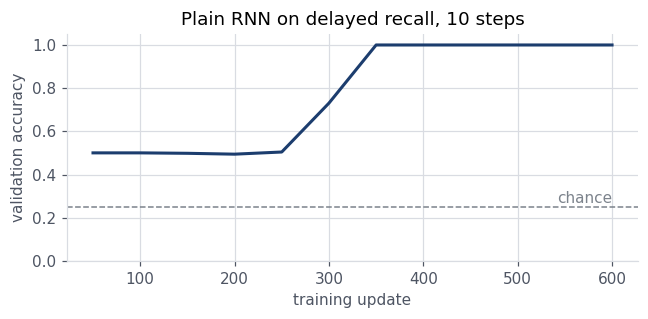

In [8]:
acc, history = train_recall("rnn", seq_len=10, seed=0)
print(f"Plain recurrent layer, 10 steps, after 600 updates: accuracy {acc:.3f}  (chance is 0.25)")

steps, accs = zip(*history)
plt.figure(figsize=(6, 3))
plt.plot(steps, accs, color=NAVY, lw=2)
plt.axhline(0.25, color=MUTED, ls="--", lw=1)
plt.text(steps[-1], 0.27, "chance", ha="right", color=MUTED)
plt.xlabel("training update")
plt.ylabel("validation accuracy")
plt.ylim(0, 1.05)
plt.title("Plain RNN on delayed recall, 10 steps")
plt.tight_layout()
plt.show()

A plain recurrent cell has no trouble when the gap is 10 steps. Part 2 shows
why that stops being true as the gap grows, and Part 3 shows what fixes it.

## Try it

1. Change `seq_len` to 20 and 25 in the training cell and run it for seeds 0 and
   1. Is the outcome the same for both seeds? What does that suggest about the
   reliability of a plain recurrent cell at moderate lengths?
2. Build `nn.LSTM(8, 32)` and `nn.GRU(8, 32)` and print `count(...)` for each.
   Explain the ratios against the plain cell (1,344).
3. In section 2, remove `b` from the update (set it to zero). Does the loop still
   match `nn.RNN`? Why not?

## What this notebook showed

- On 60-step inputs, a fully connected layer needs 15,392 parameters and rejects
  a 61-step input; the recurrent layer needs 1,344 and accepts any length.
- The hand-written recurrence matches `nn.RNN` to within floating-point error,
  once you use the **sum** of PyTorch's two bias vectors.
- `h_n` is `(num_layers, batch, hidden)` even with `batch_first=True`, and a
  wrong `batch_first` silently gives wrong numbers with the right shape.
- A plain recurrent cell solves delayed recall over a 10-step gap.